# 08 — Prophet (top 50 SKUs clase A)

**Objetivo:** Aplicar un modelo univariante especializado (Prophet, de Facebook/Meta) a los SKUs más valiosos del negocio. Comparar contra LightGBM, XGBoost y baseline en este subconjunto.

**Fase CRISP-DM:** 4 — Modelado (modelo especializado para SKUs de alto valor).

**Inputs:**
- Tabla `ventas_semanales` (MySQL) — series originales
- Tabla `clasificacion_abc_xyz` (MySQL) — para identificar top 50 clase A
- Tabla `pronosticos` (MySQL) — predicciones previas de baseline, LightGBM, XGBoost

**Outputs:**
- Predicciones de Prophet en tabla `pronosticos` (modelo='prophet')
- Métricas en tabla `metricas_modelos` (modelo='prophet')
- Descomposiciones visuales en `reports/figures/prophet/`

**¿Por qué Prophet aquí?**

Prophet es un algoritmo desarrollado por Meta para series con estacionalidad fuerte. A diferencia de LightGBM/XGBoost (multivariantes y globales), Prophet:
- Modela cada SKU individualmente (un modelo por producto).
- Descompone la serie en tendencia + estacionalidad + festivos.
- Es muy interpretable: muestra explícitamente los componentes.

**¿Por qué solo top 50?**

- Prophet es lento: ~1-2 segundos por SKU. Para 2.310 SKUs tardaría >40 minutos.
- Los top 50 SKUs clase A explican ~70-75% del valor del negocio.
- Para SKUs C (esporádicos), un modelo univariante no aporta más que el baseline.

**Hipótesis a validar:**

> Para SKUs clase A con historia robusta (≥80 semanas con venta), Prophet puede competir con LightGBM y aportar interpretabilidad (descomposición en componentes).

**Autor:** Equipo del proyecto — Diego Andrés De Jesús Montenegro y Luis David Andrade Díaz
**Fecha:** mayo 2026

In [1]:
# =========================
# Imports
# =========================
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import logging
# Silenciar logs de Prophet (son MUY ruidosos)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import text
import holidays

from prophet import Prophet

from src.db import get_engine

# Configuracion visual
COLOR_PRIMARIO = "#1F4E78"
COLOR_SECUNDARIO = "#E67E22"
COLOR_VERDE = "#27AE60"
COLOR_ROJO = "#C0392B"
COLOR_LIGHTGBM = "#9B59B6"   # Morado
COLOR_XGBOOST = "#16A085"    # Verde azulado
COLOR_PROPHET = "#E91E63"    # Rosa distintivo

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FIG_DIR = ROOT / "reports" / "figures" / "prophet"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    out = FIG_DIR / f"{nombre}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  Guardado: {out.relative_to(ROOT)}")

print("Setup completado.")

Setup completado.


## 1. Selección de top 50 SKUs clase A

Criterios:
- Clase ABC = A (alto valor).
- Al menos 80 semanas con venta en el periodo completo (historia robusta).
- Top 50 por valor total.

In [2]:
engine = get_engine()

# Top 50 SKUs clase A con historia robusta
top_skus_query = """
SELECT item, nombre_item, valor_total, num_semanas_con_venta
FROM clasificacion_abc_xyz
WHERE clase_abc = 'A' AND num_semanas_con_venta >= 80
ORDER BY valor_total DESC
LIMIT 50
"""

top_skus_df = pd.read_sql(top_skus_query, engine)
print(f"Top SKUs clase A seleccionados: {len(top_skus_df)}")
print(f"\nPrimeros 10:")
print(top_skus_df.head(10))

top_skus_lista = top_skus_df["item"].tolist()
print(f"\nValor total de los top 50: ${top_skus_df['valor_total'].sum() / 1e9:.2f} mil millones COP")

Top SKUs clase A seleccionados: 50

Primeros 10:
     item                               nombre_item         valor_total  \
0  000041              CEMENTO GRIS *50 KL T1 ARGOS 28,196,379,716.0000   
1  000291                  VARILLA CORR 1/2 * 6 MTS  9,041,477,207.0000   
2  000289                  VARILLA CORR 3/8 * 6 MTS  6,193,325,416.0000   
3  009511                      SUR CEMENTO ARGOS T1  3,260,097,586.0000   
4  000255                HIERRO DE 1/4 *KG P/FLEJES  3,209,687,304.0000   
5  010213  T1 CEMENTO GRIS * 50KG RETIRADO EN PLANT  2,917,931,206.0000   
6  000292                  VARILLA CORR 5/8 * 6 MTS  2,683,900,730.0000   
7  000551                 TEJA PROTEJA P7  6 (1.80)  2,077,059,192.0000   
8  000539            PLACA PANEL YESO GYPLAC (1/2 )  1,691,227,449.0000   
9  000548                 TEJA PROTEJA P7  10(3.05)  1,593,745,009.0000   

   num_semanas_con_venta  
0                    105  
1                    105  
2                    105  
3                

## 2. Preparación de series univariantes

Prophet requiere un DataFrame con columnas `ds` (fecha) y `y` (valor). Como cada SKU vende en varios centros, **agregamos por SKU** (sumamos los 3 centros). Esto es razonable porque a los SKUs estrella nos interesa la **demanda total** del producto.

In [3]:
# Cargar ventas semanales agregadas por SKU (sumando los 3 centros)
ventas = pd.read_sql(
    """
    SELECT item, fecha_inicio_semana, SUM(cantidad_total) AS cantidad_total
    FROM ventas_semanales
    WHERE item IN ({})
    GROUP BY item, fecha_inicio_semana
    """.format(",".join([f"'{s}'" for s in top_skus_lista])),
    engine,
    parse_dates=["fecha_inicio_semana"],
)

print(f"Filas de ventas agregadas: {len(ventas):,}")
print(f"SKUs distintos: {ventas['item'].nunique()}")
print(f"Periodo: {ventas['fecha_inicio_semana'].min().date()} -> {ventas['fecha_inicio_semana'].max().date()}")

Filas de ventas agregadas: 5,724
SKUs distintos: 50
Periodo: 2024-01-01 -> 2026-03-30


In [4]:
# Particion temporal (igual que en todos los notebooks)
FECHA_FIN_TRAIN = pd.Timestamp("2025-09-30")
FECHA_FIN_VALID = pd.Timestamp("2025-12-31")

# Expandir series con ceros (Prophet maneja mejor series continuas)
def expandir_serie_sku(df_sku, fecha_min, fecha_max):
    """Expande la serie de un SKU rellenando con cero las semanas sin venta."""
    semanas = pd.date_range(start=fecha_min, end=fecha_max, freq="W-MON")
    grid = pd.DataFrame({"fecha_inicio_semana": semanas})
    grid = grid.merge(df_sku[["fecha_inicio_semana", "cantidad_total"]],
                       on="fecha_inicio_semana", how="left")
    grid["cantidad_total"] = grid["cantidad_total"].fillna(0)
    return grid

# Construir un dict {sku: serie_expandida}
fecha_min_global = ventas["fecha_inicio_semana"].min()
fecha_max_global = ventas["fecha_inicio_semana"].max()

series_skus = {}
for sku in top_skus_lista:
    sub = ventas[ventas["item"] == sku].sort_values("fecha_inicio_semana")
    primera = sub["fecha_inicio_semana"].min()
    serie = expandir_serie_sku(sub, primera, fecha_max_global)
    serie = serie.rename(columns={"fecha_inicio_semana": "ds", "cantidad_total": "y"})
    series_skus[sku] = serie

print(f"Series construidas para {len(series_skus)} SKUs")
print(f"\nEjemplo (primer SKU): {top_skus_lista[0]}")
print(series_skus[top_skus_lista[0]].head())

Series construidas para 50 SKUs

Ejemplo (primer SKU): 000041
          ds           y
0 2024-01-01 13,576.0000
1 2024-01-08  8,088.0000
2 2024-01-15 11,290.0000
3 2024-01-22  7,340.0000
4 2024-01-29 12,484.0000


## 3. Configuración de festivos de Colombia

Prophet permite pasar un calendario de festivos como input para que modele su efecto sobre la demanda.

In [5]:
# Generar dataframe de festivos de Colombia para los anios del periodo
anios = range(fecha_min_global.year, fecha_max_global.year + 1)
festivos_co = holidays.Colombia(years=list(anios))

festivos_df = pd.DataFrame([
    {"holiday": nombre, "ds": pd.Timestamp(fecha)}
    for fecha, nombre in festivos_co.items()
])
festivos_df = festivos_df.sort_values("ds").reset_index(drop=True)
print(f"Festivos cargados: {len(festivos_df)}")
print(festivos_df.head(10))

Festivos cargados: 53
                                 holiday         ds
0                         New Year's Day 2024-01-01
1                    Epiphany (observed) 2024-01-08
2          Saint Joseph's Day (observed) 2024-03-25
3                        Maundy Thursday 2024-03-28
4                            Good Friday 2024-03-29
5                              Labor Day 2024-05-01
6               Ascension Day (observed) 2024-05-13
7              Corpus Christi (observed) 2024-06-03
8                Sacred Heart (observed) 2024-06-10
9  Saint Peter and Saint Paul (observed) 2024-07-01


## 4. Función de entrenamiento de un Prophet individual

Encapsulamos la lógica para llamarla en bucle sobre los 50 SKUs.

In [6]:
def entrenar_y_predecir_prophet(serie, fecha_fin_train, fecha_fin_valid, festivos_df):
    """Entrena Prophet con train y predice valid + test 2026.

    Args:
        serie: DataFrame con columnas 'ds' (fecha) e 'y' (cantidad)
        fecha_fin_train: ultimo dia del train
        fecha_fin_valid: ultimo dia del valid
        festivos_df: festivos para el modelo

    Returns:
        DataFrame con predicciones para valid + test (cols: ds, yhat, yhat_lower, yhat_upper, split)
    """
    # Subset de train
    train_data = serie[serie["ds"] <= fecha_fin_train].copy()

    # Inicializar Prophet con parametros razonables
    modelo = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=False,    # No tenemos granularidad diaria
        daily_seasonality=False,
        holidays=festivos_df,
        seasonality_mode="multiplicative",  # Estacionalidad escala con la magnitud
        changepoint_prior_scale=0.05,       # Flexibilidad de cambios de tendencia
        seasonality_prior_scale=10.0,
        holidays_prior_scale=10.0,
        interval_width=0.80,                 # 80% de intervalo de confianza
    )

    # Entrenar
    modelo.fit(train_data)

    # Predecir todo el periodo (train + valid + test)
    future = serie[["ds"]].copy()
    forecast = modelo.predict(future)

    # Marcar split
    forecast["split"] = "train"
    forecast.loc[(forecast["ds"] > fecha_fin_train) &
                  (forecast["ds"] <= fecha_fin_valid), "split"] = "valid"
    forecast.loc[forecast["ds"] > fecha_fin_valid, "split"] = "test_2026"

    return forecast, modelo

print("Funcion entrenar_y_predecir_prophet() lista.")

Funcion entrenar_y_predecir_prophet() lista.


## 5. Entrenamiento iterativo de los 50 modelos

Esta sección puede tardar **2-5 minutos** porque entrenamos un modelo Prophet por cada SKU.

In [7]:
import time

resultados = {}
modelos = {}
errores = []

print(f"Entrenando Prophet para {len(top_skus_lista)} SKUs...")
print("(Esto puede tomar varios minutos)\n")
inicio = time.time()

for i, sku in enumerate(top_skus_lista, 1):
    try:
        serie = series_skus[sku]
        forecast, modelo = entrenar_y_predecir_prophet(
            serie, FECHA_FIN_TRAIN, FECHA_FIN_VALID, festivos_df
        )
        # Agregar serie real para comparar
        forecast = forecast.merge(serie, on="ds", how="left")
        forecast["item"] = sku
        resultados[sku] = forecast
        modelos[sku] = modelo

        if i % 10 == 0:
            tiempo = time.time() - inicio
            print(f"  [{i:>2}/{len(top_skus_lista)}] SKU {sku} OK - {tiempo:.1f}s transcurridos")
    except Exception as e:
        errores.append((sku, str(e)))
        print(f"  ERROR en SKU {sku}: {e}")

tiempo_total = time.time() - inicio
print(f"\nEntrenamiento completado en {tiempo_total/60:.2f} minutos")
print(f"Modelos entrenados exitosamente: {len(resultados)}")
print(f"Errores: {len(errores)}")

Entrenando Prophet para 50 SKUs...
(Esto puede tomar varios minutos)



22:27:54 - cmdstanpy - INFO - Chain [1] start processing
22:27:54 - cmdstanpy - INFO - Chain [1] done processing
22:27:54 - cmdstanpy - INFO - Chain [1] start processing
22:27:54 - cmdstanpy - INFO - Chain [1] done processing
22:27:54 - cmdstanpy - INFO - Chain [1] start processing
22:27:55 - cmdstanpy - INFO - Chain [1] done processing
22:27:55 - cmdstanpy - INFO - Chain [1] start processing
22:27:55 - cmdstanpy - INFO - Chain [1] done processing
22:27:55 - cmdstanpy - INFO - Chain [1] start processing
22:27:55 - cmdstanpy - INFO - Chain [1] done processing
22:27:55 - cmdstanpy - INFO - Chain [1] start processing
22:27:55 - cmdstanpy - INFO - Chain [1] done processing
22:27:55 - cmdstanpy - INFO - Chain [1] start processing
22:27:56 - cmdstanpy - INFO - Chain [1] done processing
22:27:56 - cmdstanpy - INFO - Chain [1] start processing
22:27:56 - cmdstanpy - INFO - Chain [1] done processing
22:27:56 - cmdstanpy - INFO - Chain [1] start processing
22:27:56 - cmdstanpy - INFO - Chain [1]

  [10/50] SKU 000548 OK - 2.5s transcurridos


22:27:57 - cmdstanpy - INFO - Chain [1] done processing
22:27:57 - cmdstanpy - INFO - Chain [1] start processing
22:27:57 - cmdstanpy - INFO - Chain [1] done processing
22:27:57 - cmdstanpy - INFO - Chain [1] start processing
22:27:57 - cmdstanpy - INFO - Chain [1] done processing
22:27:57 - cmdstanpy - INFO - Chain [1] start processing
22:27:57 - cmdstanpy - INFO - Chain [1] done processing
22:27:57 - cmdstanpy - INFO - Chain [1] start processing
22:27:58 - cmdstanpy - INFO - Chain [1] done processing
22:27:58 - cmdstanpy - INFO - Chain [1] start processing
22:27:58 - cmdstanpy - INFO - Chain [1] done processing
22:27:58 - cmdstanpy - INFO - Chain [1] start processing
22:27:58 - cmdstanpy - INFO - Chain [1] done processing
22:27:58 - cmdstanpy - INFO - Chain [1] start processing
22:27:58 - cmdstanpy - INFO - Chain [1] done processing
22:27:58 - cmdstanpy - INFO - Chain [1] start processing
22:27:58 - cmdstanpy - INFO - Chain [1] done processing
22:27:58 - cmdstanpy - INFO - Chain [1] 

  [20/50] SKU 000262 OK - 4.3s transcurridos


...

  [30/50] SKU 002838 OK - 6.2s transcurridos


22:28:01 - cmdstanpy - INFO - Chain [1] done processing
22:28:01 - cmdstanpy - INFO - Chain [1] start processing
22:28:01 - cmdstanpy - INFO - Chain [1] done processing
22:28:01 - cmdstanpy - INFO - Chain [1] start processing
22:28:01 - cmdstanpy - INFO - Chain [1] done processing
22:28:01 - cmdstanpy - INFO - Chain [1] start processing
22:28:01 - cmdstanpy - INFO - Chain [1] done processing
22:28:01 - cmdstanpy - INFO - Chain [1] start processing
22:28:01 - cmdstanpy - INFO - Chain [1] done processing
22:28:01 - cmdstanpy - INFO - Chain [1] start processing
22:28:02 - cmdstanpy - INFO - Chain [1] done processing
22:28:02 - cmdstanpy - INFO - Chain [1] start processing
22:28:02 - cmdstanpy - INFO - Chain [1] done processing
22:28:02 - cmdstanpy - INFO - Chain [1] start processing
22:28:02 - cmdstanpy - INFO - Chain [1] done processing
22:28:02 - cmdstanpy - INFO - Chain [1] start processing
22:28:02 - cmdstanpy - INFO - Chain [1] done processing
22:28:02 - cmdstanpy - INFO - Chain [1] 

  [40/50] SKU 006620 OK - 8.0s transcurridos


22:28:02 - cmdstanpy - INFO - Chain [1] done processing
22:28:02 - cmdstanpy - INFO - Chain [1] start processing
22:28:02 - cmdstanpy - INFO - Chain [1] done processing
22:28:02 - cmdstanpy - INFO - Chain [1] start processing
22:28:03 - cmdstanpy - INFO - Chain [1] done processing
22:28:03 - cmdstanpy - INFO - Chain [1] start processing
22:28:03 - cmdstanpy - INFO - Chain [1] done processing
22:28:03 - cmdstanpy - INFO - Chain [1] start processing
22:28:03 - cmdstanpy - INFO - Chain [1] done processing
22:28:03 - cmdstanpy - INFO - Chain [1] start processing
22:28:03 - cmdstanpy - INFO - Chain [1] done processing
22:28:03 - cmdstanpy - INFO - Chain [1] start processing
22:28:03 - cmdstanpy - INFO - Chain [1] done processing
22:28:03 - cmdstanpy - INFO - Chain [1] start processing
22:28:03 - cmdstanpy - INFO - Chain [1] done processing
22:28:03 - cmdstanpy - INFO - Chain [1] start processing
22:28:04 - cmdstanpy - INFO - Chain [1] done processing


  [50/50] SKU 000283 OK - 9.7s transcurridos

Entrenamiento completado en 0.16 minutos
Modelos entrenados exitosamente: 50
Errores: 0


In [8]:
# Diagnostico rapido
print(f"Modelos entrenados (dict 'resultados'): {len(resultados)}")
print(f"Errores capturados (lista 'errores'): {len(errores)}")
print(f"Modelos en dict 'modelos': {len(modelos)}")

if len(errores) > 0:
    print("\n=== ERRORES (primeros 5) ===")
    for sku, err in errores[:5]:
        print(f"\nSKU {sku}:")
        print(f"  {err}")
elif len(resultados) == 0:
    print("\nNi resultados ni errores. Algo raro pasó.")
    print("Verificando series_skus...")
    print(f"  series_skus tiene {len(series_skus)} entradas")
    if len(series_skus) > 0:
        primer_sku = list(series_skus.keys())[0]
        print(f"  Ejemplo serie del SKU {primer_sku}:")
        print(series_skus[primer_sku].head())
        print(f"  Longitud: {len(series_skus[primer_sku])}")

Modelos entrenados (dict 'resultados'): 50
Errores capturados (lista 'errores'): 0
Modelos en dict 'modelos': 50


## 6. Consolidar predicciones

In [9]:
# Construir DataFrame consolidado con todas las predicciones
prophet_preds = pd.concat(resultados.values(), ignore_index=True)
prophet_preds["yhat"] = prophet_preds["yhat"].clip(lower=0)  # No predicciones negativas

print(f"Predicciones totales: {len(prophet_preds):,}")
print(f"\nDistribucion por split:")
print(prophet_preds["split"].value_counts())
print()
print("Primeras filas:")
prophet_preds[["item", "ds", "y", "yhat", "yhat_lower", "yhat_upper", "split"]].head()

Predicciones totales: 5,891

Distribucion por split:
split
train        4591
valid         650
test_2026     650
Name: count, dtype: int64

Primeras filas:


,item,ds,y,yhat,yhat_lower,yhat_upper,split
0,000041,2024-01-01,"13,576.0000","13,596.9379","7,591.0983","19,106.6221",train
1,000041,2024-01-08,"8,088.0000","8,122.7655","2,379.7726","13,567.9311",train
2,000041,2024-01-15,"11,290.0000","10,578.4834","4,921.0628","16,015.8970",train
3,000041,2024-01-22,"7,340.0000","8,797.4846","3,214.2679","14,348.9311",train
4,000041,2024-01-29,"12,484.0000","9,607.6504","4,029.1252","15,660.1679",train


## 7. Métricas globales (sobre los top 50 SKUs)

In [10]:
def calcular_metricas(y_real, y_pred, nombre=""):
    """Calcula MAE, RMSE, MAPE y sMAPE."""
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_real - y_pred
    abs_error = np.abs(error)

    mae = abs_error.mean()
    rmse = np.sqrt((error ** 2).mean())

    mask_no_cero = y_real > 0
    mape = (abs_error[mask_no_cero] / y_real[mask_no_cero]).mean() * 100 if mask_no_cero.sum() > 0 else np.nan

    denominador = (np.abs(y_real) + np.abs(y_pred)) / 2
    mask_smape = denominador > 0
    smape = (abs_error[mask_smape] / denominador[mask_smape]).mean() * 100 if mask_smape.sum() > 0 else np.nan

    metricas = {"n_obs": len(y_real), "mae": mae, "rmse": rmse, "mape": mape, "smape": smape}

    if nombre:
        print(f"{nombre}:")
        print(f"  N observaciones: {metricas['n_obs']:>8,}")
        print(f"  MAE:             {metricas['mae']:>8.4f}")
        print(f"  RMSE:            {metricas['rmse']:>8.4f}")
        print(f"  MAPE:            {metricas['mape']:>8.2f}%")
        print(f"  sMAPE:           {metricas['smape']:>8.2f}%")

    return metricas

# Metricas en valid y test 2026
valid_proph = prophet_preds[prophet_preds["split"] == "valid"]
test_proph = prophet_preds[prophet_preds["split"] == "test_2026"]

metricas_valid = calcular_metricas(valid_proph["y"], valid_proph["yhat"],
                                    nombre="PROPHET EN VALIDATION (top 50 SKUs A)")
print()
metricas_test = calcular_metricas(test_proph["y"], test_proph["yhat"],
                                   nombre="PROPHET EN TEST 2026 (top 50 SKUs A)")

PROPHET EN VALIDATION (top 50 SKUs A):
  N observaciones:      650
  MAE:             914.4257
  RMSE:            2480.7276
  MAPE:              195.08%
  sMAPE:              76.99%

PROPHET EN TEST 2026 (top 50 SKUs A):
  N observaciones:      650
  MAE:             711.7805
  RMSE:            1825.4509
  MAPE:              224.25%
  sMAPE:              75.21%


## 8. Comparación 4 modelos SOLO sobre los top 50 SKUs

⚠️ **Comparación justa**: tenemos que comparar las métricas de los otros modelos **únicamente sobre los mismos 50 SKUs** (agregando por SKU, no por SKU×centro). Las métricas globales reportadas en los notebooks anteriores son sobre TODOS los SKUs.

In [11]:
# Cargar predicciones de los otros 3 modelos, agregadas por SKU x semana
otros_preds = pd.read_sql(
    """
    SELECT modelo, item, fecha_inicio_semana,
           SUM(cantidad_real) AS y_real,
           SUM(cantidad_predicha) AS y_pred
    FROM pronosticos
    WHERE item IN ({}) AND modelo IN ('baseline_ma4', 'lightgbm', 'xgboost')
    GROUP BY modelo, item, fecha_inicio_semana
    """.format(",".join([f"'{s}'" for s in top_skus_lista])),
    engine,
    parse_dates=["fecha_inicio_semana"],
)
print(f"Predicciones de los otros 3 modelos cargadas: {len(otros_preds):,} filas")
print(f"Modelos: {otros_preds['modelo'].unique()}")

Predicciones de los otros 3 modelos cargadas: 3,900 filas
Modelos: ['baseline_ma4' 'lightgbm' 'xgboost']


In [12]:
# Calcular metricas por modelo solo sobre top 50 SKUs
def metricas_por_modelo(df, valor_real_col, valor_pred_col):
    return calcular_metricas(df[valor_real_col], df[valor_pred_col])

# Necesitamos saber el split. Lo asignamos por fecha
def asignar_split(fecha):
    if fecha <= FECHA_FIN_TRAIN: return "train"
    elif fecha <= FECHA_FIN_VALID: return "valid"
    else: return "test_2026"

otros_preds["split"] = otros_preds["fecha_inicio_semana"].apply(asignar_split)

# Construir tabla comparativa
tabla_comp = []
for modelo_nombre, modelo_df in [
    ("baseline_ma4", otros_preds[otros_preds["modelo"] == "baseline_ma4"]),
    ("lightgbm",     otros_preds[otros_preds["modelo"] == "lightgbm"]),
    ("xgboost",      otros_preds[otros_preds["modelo"] == "xgboost"]),
]:
    for split_n in ["valid", "test_2026"]:
        sub = modelo_df[modelo_df["split"] == split_n]
        m = calcular_metricas(sub["y_real"], sub["y_pred"])
        tabla_comp.append({
            "modelo": modelo_nombre, "split": split_n,
            "mae": m["mae"], "rmse": m["rmse"],
            "mape": m["mape"], "smape": m["smape"], "n_obs": m["n_obs"],
        })

# Agregar Prophet
for split_n, m_dict in [("valid", metricas_valid), ("test_2026", metricas_test)]:
    tabla_comp.append({
        "modelo": "prophet", "split": split_n,
        "mae": m_dict["mae"], "rmse": m_dict["rmse"],
        "mape": m_dict["mape"], "smape": m_dict["smape"], "n_obs": m_dict["n_obs"],
    })

tabla_comp_df = pd.DataFrame(tabla_comp)
print("Comparacion de 4 modelos SOLO sobre los top 50 SKUs clase A:")
print(tabla_comp_df.pivot(index="modelo", columns="split", values="mae").round(2))

Comparacion de 4 modelos SOLO sobre los top 50 SKUs clase A:
split         test_2026    valid
modelo                          
baseline_ma4   525.0900 714.8900
lightgbm        86.6700 128.5200
prophet        711.7800 914.4300
xgboost        167.2300 224.2800


  Guardado: reports/figures/prophet/01_comparacion_4_modelos.png


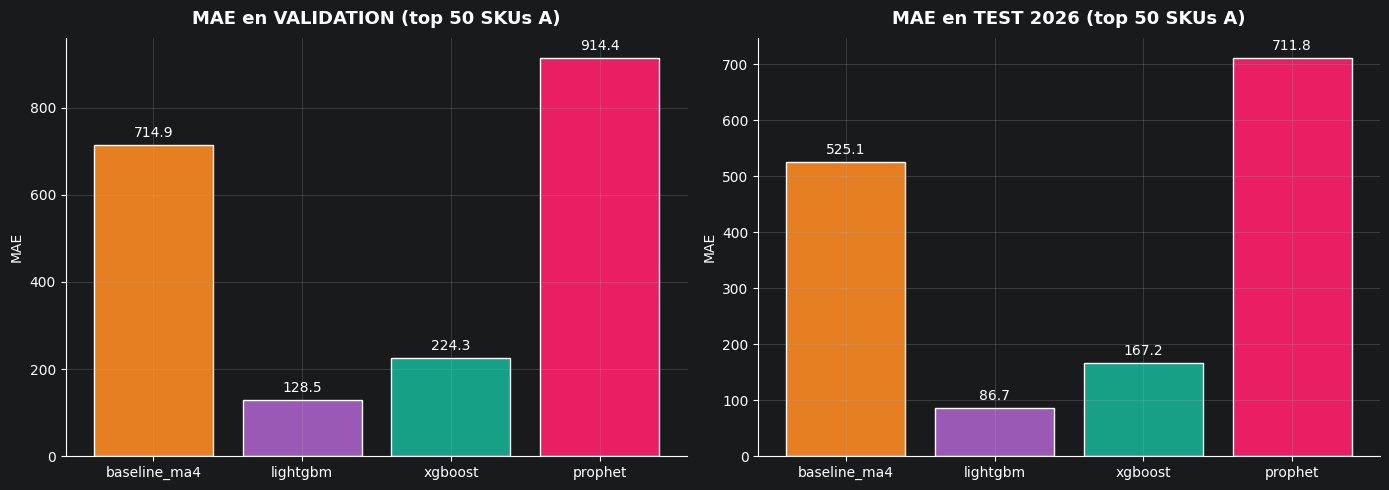

In [13]:
# Visualizacion comparativa: MAE de los 4 modelos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_mae = tabla_comp_df.pivot(index="modelo", columns="split", values="mae")
pivot_mae = pivot_mae.reindex(["baseline_ma4", "lightgbm", "xgboost", "prophet"])

# Validation
axes[0].bar(pivot_mae.index, pivot_mae["valid"],
            color=[COLOR_SECUNDARIO, COLOR_LIGHTGBM, COLOR_XGBOOST, COLOR_PROPHET],
            edgecolor="white")
axes[0].set_title("MAE en VALIDATION (top 50 SKUs A)", pad=10)
axes[0].set_ylabel("MAE")
for i, v in enumerate(pivot_mae["valid"]):
    axes[0].text(i, v + max(pivot_mae["valid"]) * 0.02, f"{v:.1f}",
                  ha="center", fontsize=10)

# Test 2026
axes[1].bar(pivot_mae.index, pivot_mae["test_2026"],
            color=[COLOR_SECUNDARIO, COLOR_LIGHTGBM, COLOR_XGBOOST, COLOR_PROPHET],
            edgecolor="white")
axes[1].set_title("MAE en TEST 2026 (top 50 SKUs A)", pad=10)
axes[1].set_ylabel("MAE")
for i, v in enumerate(pivot_mae["test_2026"]):
    axes[1].text(i, v + max(pivot_mae["test_2026"]) * 0.02, f"{v:.1f}",
                  ha="center", fontsize=10)

plt.tight_layout()
guardar(fig, "01_comparacion_4_modelos")
plt.show()

## 9. Descomposición visual de componentes

Una de las ventajas más valiosas de Prophet: muestra explícitamente la **tendencia**, **estacionalidad** y **efectos de festivos** para cada SKU. Visualizamos los 4 SKUs top.

  Guardado: reports/figures/prophet/02_descomposicion_000041.png


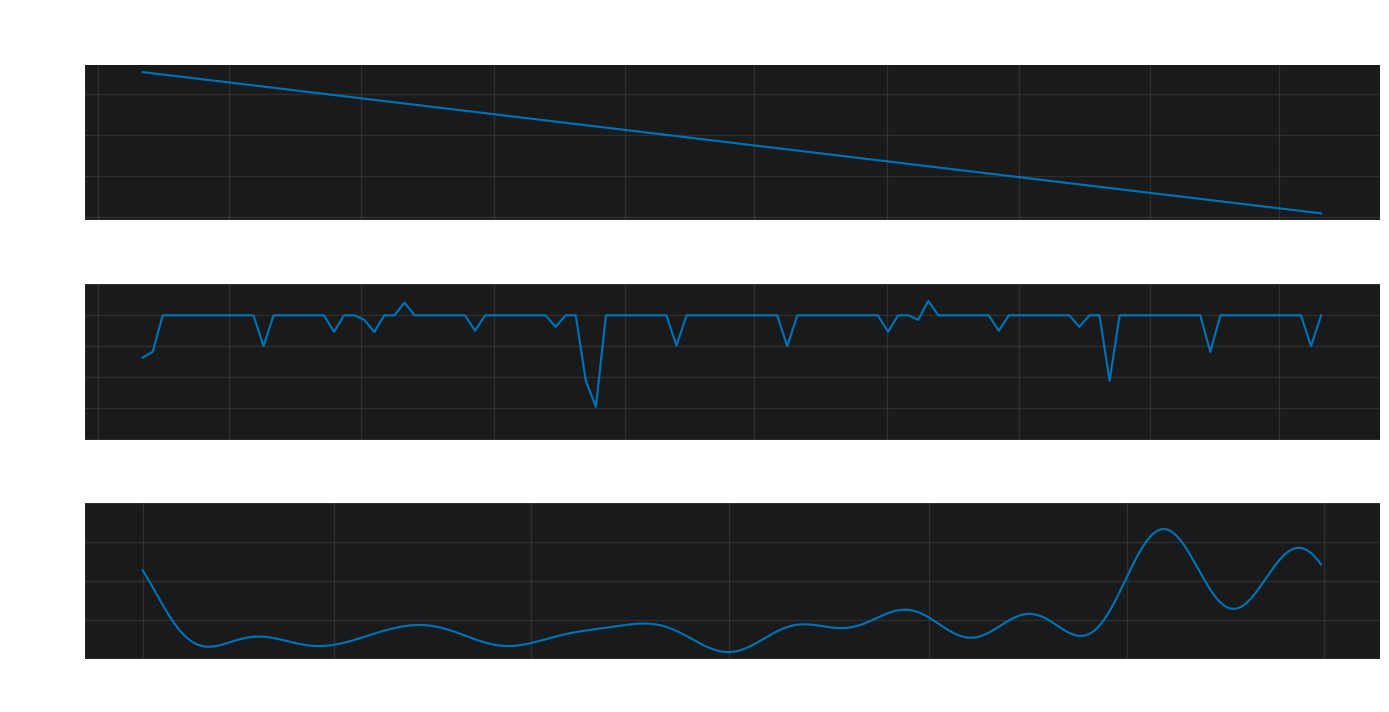

  Guardado: reports/figures/prophet/02_descomposicion_000291.png


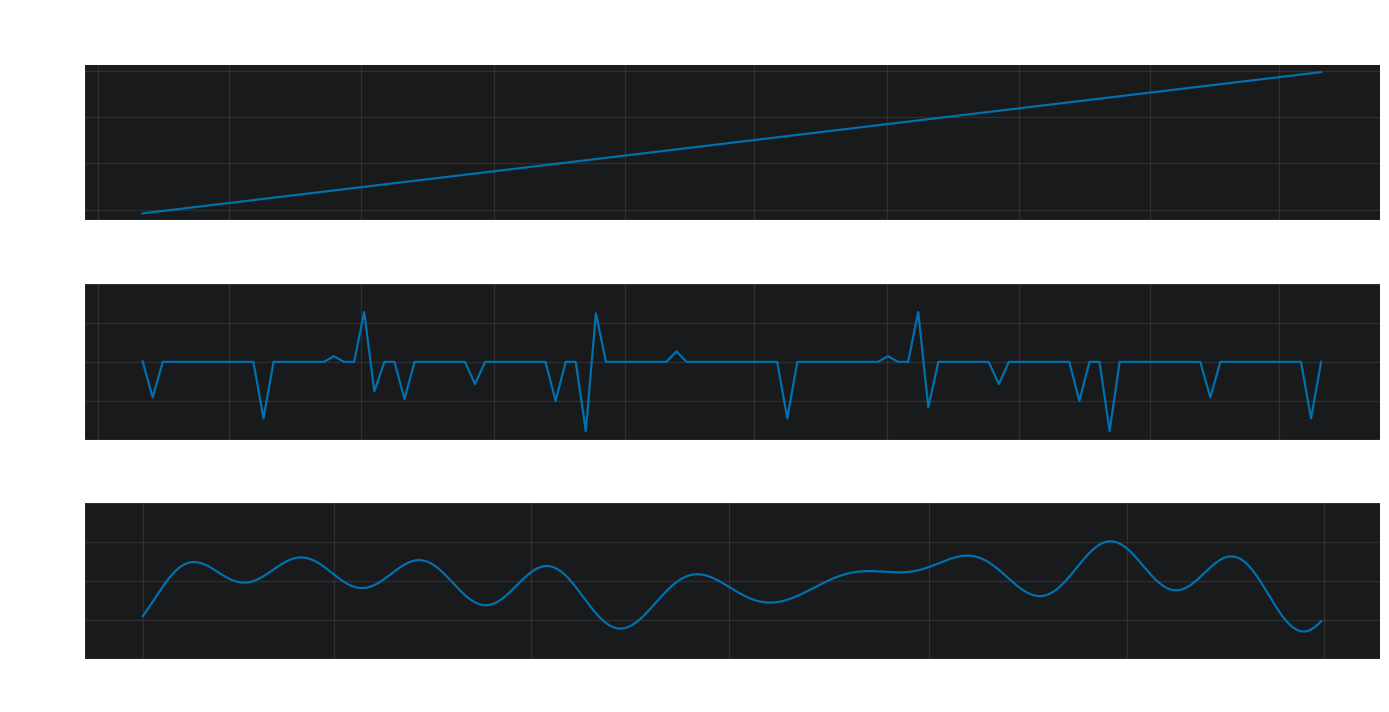

  Guardado: reports/figures/prophet/02_descomposicion_000289.png


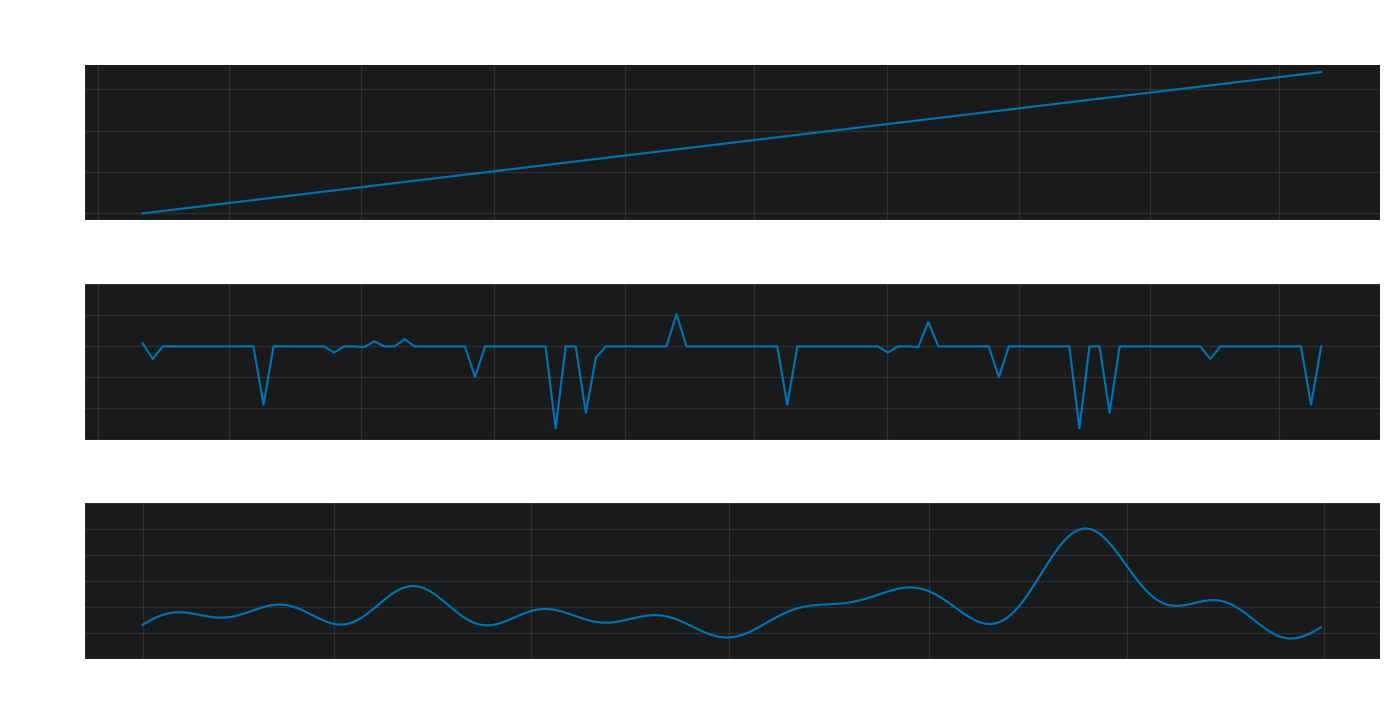

  Guardado: reports/figures/prophet/02_descomposicion_009511.png


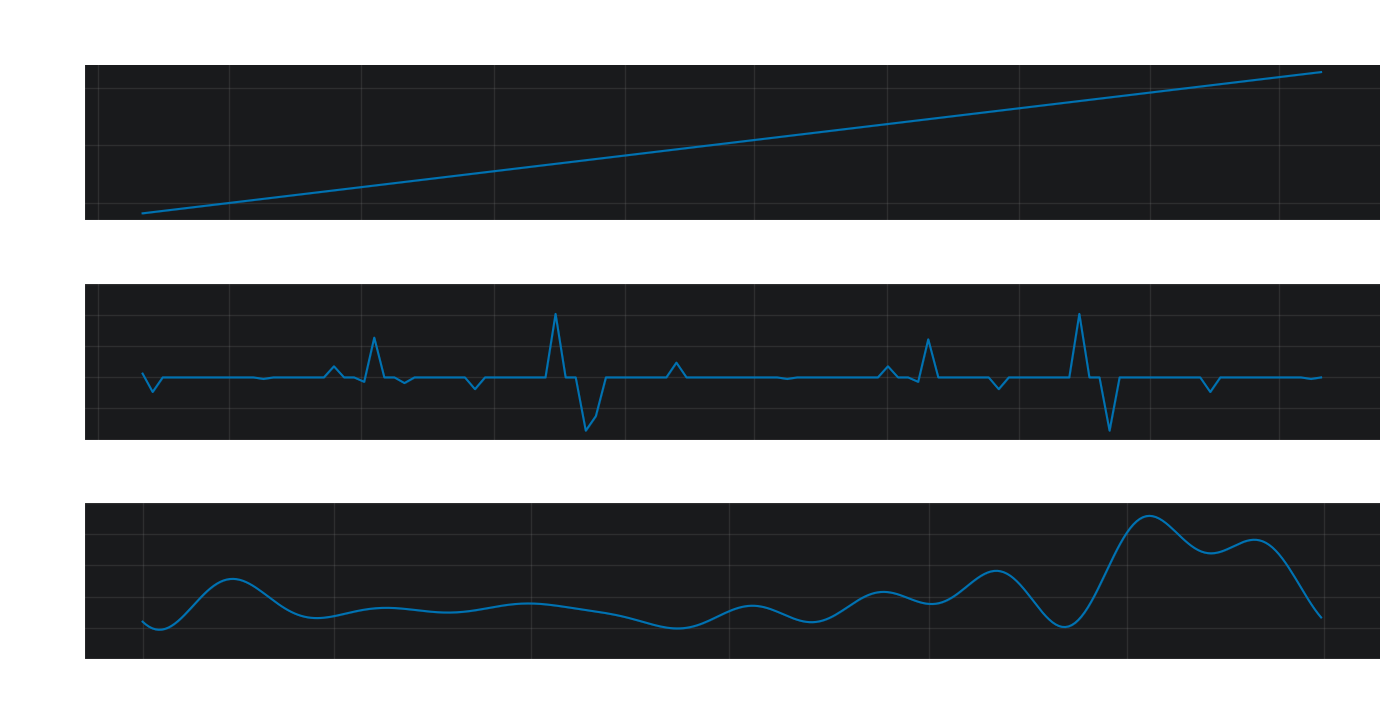

In [14]:
# Top 4 SKUs (los mismos que hemos usado)
skus_a_visualizar = top_skus_lista[:4]

for sku in skus_a_visualizar:
    if sku not in modelos:
        continue
    modelo_sku = modelos[sku]
    forecast = resultados[sku]

    fig = modelo_sku.plot_components(forecast, figsize=(14, 7))
    fig.suptitle(f"Descomposicion Prophet — SKU {sku}", y=1.01, fontsize=12)
    plt.tight_layout()
    guardar(fig, f"02_descomposicion_{sku}")
    plt.show()

## 10. Comparación visual: los 4 modelos sobre los top 4 SKUs

  Guardado: reports/figures/prophet/03_comparacion_4_modelos_top4.png


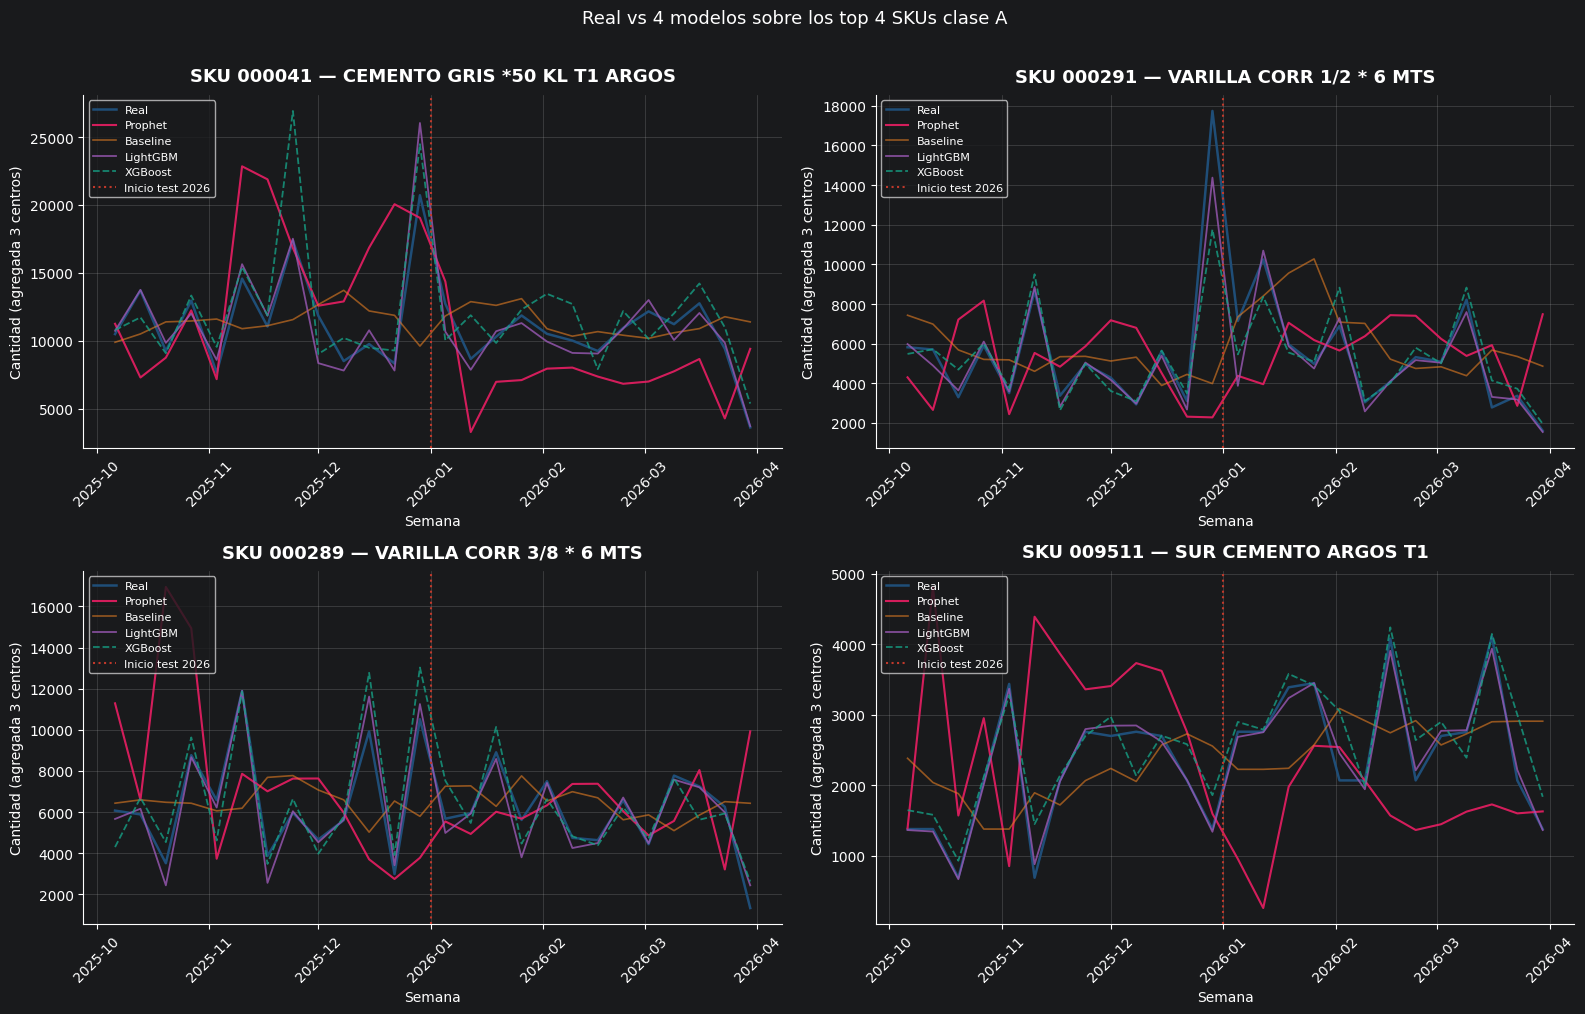

In [15]:
# Para visualizar Prophet vs los otros modelos en los top 4 SKUs
# Necesitamos las predicciones de los otros 3 modelos sobre los mismos SKUs

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, sku in enumerate(skus_a_visualizar):
    ax = axes[i]
    if sku not in resultados:
        continue

    # Prophet
    forecast = resultados[sku]
    forecast_plot = forecast[forecast["split"].isin(["valid", "test_2026"])]

    # Otros modelos (suma por SKU x semana, ya esta agregado)
    otros = otros_preds[otros_preds["item"] == sku]
    otros_pivot = otros.pivot_table(
        index="fecha_inicio_semana", columns="modelo",
        values="y_pred", aggfunc="first"
    ).reset_index()

    # Plotear real
    ax.plot(forecast_plot["ds"], forecast_plot["y"],
            label="Real", color=COLOR_PRIMARIO, linewidth=1.8)

    # Plotear Prophet
    ax.plot(forecast_plot["ds"], forecast_plot["yhat"],
            label="Prophet", color=COLOR_PROPHET, linewidth=1.5, alpha=0.9)

    # Plotear otros modelos
    if "baseline_ma4" in otros_pivot.columns:
        ax.plot(otros_pivot["fecha_inicio_semana"], otros_pivot["baseline_ma4"],
                label="Baseline", color=COLOR_SECUNDARIO, linewidth=1.2, alpha=0.6)
    if "lightgbm" in otros_pivot.columns:
        ax.plot(otros_pivot["fecha_inicio_semana"], otros_pivot["lightgbm"],
                label="LightGBM", color=COLOR_LIGHTGBM, linewidth=1.3, alpha=0.8)
    if "xgboost" in otros_pivot.columns:
        ax.plot(otros_pivot["fecha_inicio_semana"], otros_pivot["xgboost"],
                label="XGBoost", color=COLOR_XGBOOST, linewidth=1.3, alpha=0.8,
                linestyle="--")

    ax.axvline(pd.Timestamp("2026-01-01"), color=COLOR_ROJO, linestyle=":",
                linewidth=1.5, label="Inicio test 2026")

    nombre_sku = top_skus_df[top_skus_df["item"] == sku]["nombre_item"].iloc[0][:35]
    ax.set_title(f"SKU {sku} — {nombre_sku}", pad=10)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Cantidad (agregada 3 centros)")
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Real vs 4 modelos sobre los top 4 SKUs clase A", y=1.01, fontsize=13)
plt.tight_layout()
guardar(fig, "03_comparacion_4_modelos_top4")
plt.show()

## 11. Análisis: ¿En qué SKUs Prophet aporta valor?

In [16]:
# Para cada SKU, calcular el MAE de cada modelo y ver cual es mejor
analisis_skus = []
for sku in top_skus_lista:
    if sku not in resultados:
        continue

    # MAE de Prophet (valid + test)
    forecast = resultados[sku]
    forecast_vt = forecast[forecast["split"].isin(["valid", "test_2026"])]
    mae_prophet = np.abs(forecast_vt["y"] - forecast_vt["yhat"]).mean()

    # MAE de los otros modelos (valid + test)
    otros_sku = otros_preds[otros_preds["item"] == sku]
    otros_sku = otros_sku[otros_sku["split"].isin(["valid", "test_2026"])]
    mae_otros = otros_sku.groupby("modelo").apply(
        lambda d: np.abs(d["y_real"] - d["y_pred"]).mean()
    ).to_dict()

    analisis_skus.append({
        "item": sku,
        "mae_prophet": mae_prophet,
        "mae_baseline": mae_otros.get("baseline_ma4", np.nan),
        "mae_lightgbm": mae_otros.get("lightgbm", np.nan),
        "mae_xgboost":  mae_otros.get("xgboost", np.nan),
    })

analisis_df = pd.DataFrame(analisis_skus)

# Para cada SKU, marcar el mejor modelo
def mejor_modelo(row):
    modelos_dic = {
        "prophet":  row["mae_prophet"],
        "baseline": row["mae_baseline"],
        "lightgbm": row["mae_lightgbm"],
        "xgboost":  row["mae_xgboost"],
    }
    valores_validos = {k: v for k, v in modelos_dic.items() if pd.notna(v)}
    return min(valores_validos, key=valores_validos.get) if valores_validos else None

analisis_df["mejor_modelo"] = analisis_df.apply(mejor_modelo, axis=1)

# Conteo de cuantos SKUs gana cada modelo
print("En cuantos SKUs gana cada modelo (MAE menor en valid+test):")
print(analisis_df["mejor_modelo"].value_counts())
print()
print("MAE promedio por modelo (sobre los top 50 SKUs):")
print(analisis_df[["mae_baseline", "mae_lightgbm", "mae_xgboost", "mae_prophet"]].mean().round(2))

En cuantos SKUs gana cada modelo (MAE menor en valid+test):
mejor_modelo
lightgbm    50
Name: count, dtype: int64

MAE promedio por modelo (sobre los top 50 SKUs):
mae_baseline   619.9900
mae_lightgbm   107.6000
mae_xgboost    195.7500
mae_prophet    901.0700
dtype: float64


In [17]:
# Top 10 SKUs donde Prophet es el mejor (si los hay)
skus_prophet_gana = analisis_df[analisis_df["mejor_modelo"] == "prophet"].sort_values(
    "mae_prophet", ascending=False
).head(10)

if len(skus_prophet_gana) > 0:
    print(f"Top SKUs donde Prophet aporta mas valor ({len(skus_prophet_gana)} mostrados):")
    print(skus_prophet_gana[["item", "mae_prophet", "mae_lightgbm",
                               "mae_xgboost", "mae_baseline"]].round(2))
else:
    print("Prophet no es el mejor modelo en ningun SKU.")
    print("Esto sugiere que el enfoque global de LightGBM/XGBoost domina sobre el univariante.")

Prophet no es el mejor modelo en ningun SKU.
Esto sugiere que el enfoque global de LightGBM/XGBoost domina sobre el univariante.


## 12. Guardado en MySQL

In [18]:
# Construir tabla de pronosticos para guardar
prophet_to_save = prophet_preds[prophet_preds["split"].isin(["valid", "test_2026"])].copy()
prophet_to_save = prophet_to_save[["item", "ds", "y", "yhat", "split"]].rename(columns={
    "ds": "fecha_inicio_semana",
    "y": "cantidad_real",
    "yhat": "cantidad_predicha",
})
prophet_to_save["centro_operacion"] = "TODOS"   # Prophet agrega los 3 centros
prophet_to_save["modelo"] = "prophet"
prophet_to_save = prophet_to_save[["item", "centro_operacion", "fecha_inicio_semana",
                                    "cantidad_real", "cantidad_predicha", "split", "modelo"]]

with engine.begin() as conn:
    conn.execute(text("DELETE FROM pronosticos WHERE modelo = 'prophet'"))

print(f"Guardando {len(prophet_to_save):,} predicciones de Prophet...")
prophet_to_save.to_sql("pronosticos", engine, if_exists="append", index=False, chunksize=1000)

with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM pronosticos WHERE modelo='prophet'")).scalar()
print(f"Predicciones Prophet guardadas: {n:,} filas")

Guardando 1,300 predicciones de Prophet...
Predicciones Prophet guardadas: 1,300 filas


In [19]:
# Guardar metricas (solo global, no por segmento ABC porque todos son clase A)
metricas_resumen = pd.DataFrame([
    {"modelo": "prophet", "split": "valid", "segmento": "top50_clase_A",
     "mae": metricas_valid["mae"], "rmse": metricas_valid["rmse"],
     "mape": metricas_valid["mape"], "smape": metricas_valid["smape"],
     "n_obs": metricas_valid["n_obs"]},
    {"modelo": "prophet", "split": "test_2026", "segmento": "top50_clase_A",
     "mae": metricas_test["mae"], "rmse": metricas_test["rmse"],
     "mape": metricas_test["mape"], "smape": metricas_test["smape"],
     "n_obs": metricas_test["n_obs"]},
])

with engine.begin() as conn:
    conn.execute(text("DELETE FROM metricas_modelos WHERE modelo = 'prophet'"))

metricas_resumen.to_sql("metricas_modelos", engine, if_exists="append", index=False)
print(f"Metricas guardadas: {len(metricas_resumen)} filas en tabla metricas_modelos.")
metricas_resumen

Metricas guardadas: 2 filas en tabla metricas_modelos.


,modelo,split,segmento,mae,rmse,mape,smape,n_obs
0,prophet,valid,top50_clase_A,914.4257,"2,480.7276",195.0758,76.9855,650
1,prophet,test_2026,top50_clase_A,711.7805,"1,825.4509",224.2509,75.2112,650


## 13. Resumen final

In [20]:
print("=" * 80)
print("PROPHET — RESUMEN FINAL (top 50 SKUs clase A)")
print("=" * 80)
print(f"\nModelos entrenados: {len(resultados)} / {len(top_skus_lista)} SKUs")
print(f"Errores: {len(errores)}")
print()
print(f"Metricas globales (sobre top 50 SKUs A, agregados por SKU x semana):")
print()
print(f"{'Metrica':<10} {'Validation':>15} {'Test 2026':>15}")
print("-" * 80)
for m in ["mae", "rmse", "mape", "smape"]:
    sufijo = "%" if m in ["mape", "smape"] else ""
    print(f"  {m.upper():<8} {metricas_valid[m]:>14.2f}{sufijo}  {metricas_test[m]:>14.2f}{sufijo}")
print()
print("Comparacion en estos mismos top 50 SKUs:")
pivot = tabla_comp_df.pivot(index="modelo", columns="split", values="mae").round(2)
pivot = pivot.reindex(["baseline_ma4", "lightgbm", "xgboost", "prophet"])
print(pivot)
print()
print(f"En cuantos SKUs gana cada modelo:")
print(analisis_df["mejor_modelo"].value_counts().to_string())
print()
print(f"Archivos generados:")
print(f"  - Predicciones MySQL: tabla pronosticos (modelo='prophet')")
print(f"  - Metricas MySQL: tabla metricas_modelos (modelo='prophet')")
print(f"  - Descomposiciones visuales: reports/figures/prophet/")
print(f"\nSiguiente paso: notebook 09 (evaluacion final con los 4 modelos).")
print("=" * 80)

PROPHET — RESUMEN FINAL (top 50 SKUs clase A)

Modelos entrenados: 50 / 50 SKUs
Errores: 0

Metricas globales (sobre top 50 SKUs A, agregados por SKU x semana):

Metrica         Validation       Test 2026
--------------------------------------------------------------------------------
  MAE              914.43          711.78
  RMSE            2480.73         1825.45
  MAPE             195.08%          224.25%
  SMAPE             76.99%           75.21%

Comparacion en estos mismos top 50 SKUs:
split         test_2026    valid
modelo                          
baseline_ma4   525.0900 714.8900
lightgbm        86.6700 128.5200
xgboost        167.2300 224.2800
prophet        711.7800 914.4300

En cuantos SKUs gana cada modelo:
mejor_modelo
lightgbm    50

Archivos generados:
  - Predicciones MySQL: tabla pronosticos (modelo='prophet')
  - Metricas MySQL: tabla metricas_modelos (modelo='prophet')
  - Descomposiciones visuales: reports/figures/prophet/

Siguiente paso: notebook 09 (evaluacio

### Lectura para el informe (Capítulo 5)

Prophet es un modelo univariante que se entrena **un modelo por SKU**, contrastando con el enfoque global de LightGBM/XGBoost. Sus ventajas son:

1. **Interpretabilidad**: descompone explícitamente la serie en tendencia + estacionalidad + festivos.
2. **Especialización**: cada SKU tiene su propio modelo, ajustado a su patrón individual.
3. **Manejo nativo de festivos**: a través del calendario de Colombia.

Sus desventajas en este proyecto:

1. **Costo computacional**: 50 modelos vs 1 global.
2. **No usa features externas** (categóricas, lags cruzados, etc.).
3. **Sensibilidad a series con muchos ceros**: incluso en SKUs clase A hay esporadicidad.

**El uso recomendado de Prophet en este proyecto:** complementar a LightGBM con un **enfoque interpretativo** sobre los SKUs estrella. La descomposición de componentes ayuda a entender la **estacionalidad y tendencia** de los productos críticos del negocio, información valiosa para planificación a más largo plazo.

### Próximo paso

- **Notebook 09 — Evaluación final:** comparación lado a lado de los 4 modelos, con conclusiones definitivas y recomendaciones para producción.